## What is $\tau^2$-bench

To evaluate LLM agents that interact with users, tools, and real-world systems, we need benchmarks.

**$\tau$-bench** evaluate agents that must:

- converse with users
- use tools and external APIs
- follow domain specific rules

It simulates realistic customer-service scenarios such as retail and airline support.

**$\tau^2$-bench** extends this setup with a dual-control environment in which both the agent and the user can take actions via tools, making the interactions more realistic.

**Websites:**

- https://taubench.com/

**Papers:**

- [τ-bench: A Benchmark for Tool-Agent-User Interaction in Real-World Domains](https://arxiv.org/abs/2406.12045)
- [τ^2-Bench: Evaluating Conversational Agents in a Dual-Control Environment](https://arxiv.org/abs/2506.07982)
- [τ -Knowledge: Evaluating Conversational Agents over Unstructured Knowledge](https://arxiv.org/abs/2603.04370)

**Github:**

- https://github.com/sierra-research/tau-bench
- https://github.com/sierra-research/tau2-bench

In [1]:
!uv pip install "git+https://github.com/sierra-research/tau2-bench.git"

Resolved 72 packages in 2.22s                                        
Prepared 15 packages in 14.43s                                           
Installed 26 packages in 66ms                               
 + addict==2.4.0
 + aiohappyeyeballs==2.6.1
 + aiohttp==3.13.5
 + aiosignal==1.4.0
 + deepdiff==9.0.0
 + docstring-parser==0.18.0
 + fastapi==0.136.1
 + fastuuid==0.14.0
 + frozenlist==1.8.0
 + importlib-metadata==9.0.0
 + litellm==1.82.6
 + loguru==0.7.3
 + multidict==6.7.1
 + orderly-set==5.5.0
 + pandas==3.0.2
 + propcache==0.4.1
 + python-dotenv==1.2.2
 + starlette==1.0.0
 + tabulate==0.10.0
 + tau2==1.0.0 (from git+https://github.com/sierra-research/tau2-bench.git@2be691669909439cf88dedc13decf94b7664d262)
 + tenacity==9.1.4
 + tiktoken==0.12.0
 + toml==0.10.2
 + uvicorn==0.46.0
 + yarl==1.23.0
 + zipp==3.23.1


In [4]:
# !tau2 play

## Building an Airline Agent

We are implementing a flight booking assistant.

This agent must do the following:

* understand the user’s travel request
* gather any missing information
* search for flights via APIs
* follow booking rules and constraints
* complete the reservation

This scenario captures many of the core challenges of real-world AI agents: multi-turn dialogue, planning, tool use, and rule-following.

In [2]:
import getpass

OPENAI_API_KEY = getpass.getpass("Enter your API key:")

Enter your API key: ········


In [3]:
from openai import OpenAI

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=OPENAI_API_KEY,
)

In [6]:
import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, TypedDict


DOMAIN_DIR = Path("data/tau2/domains/airline")

In [10]:
from IPython.display import Markdown, display

display(Markdown((DOMAIN_DIR / "policy.md").read_text()))

# Airline Agent Policy

The current time is 2024-05-15 15:00:00 EST.

As an airline agent, you can help users **book**, **modify**, or **cancel** flight reservations. You also handle **refunds and compensation**.

Before taking any actions that update the booking database (booking, modifying flights, editing baggage, changing cabin class, or updating passenger information), you must list the action details and obtain explicit user confirmation (yes) to proceed.

You should not provide any information, knowledge, or procedures not provided by the user or available tools, or give subjective recommendations or comments.

You should only make one tool call at a time, and if you make a tool call, you should not respond to the user simultaneously. If you respond to the user, you should not make a tool call at the same time.

You should deny user requests that are against this policy.

You should transfer the user to a human agent if and only if the request cannot be handled within the scope of your actions. To transfer, first make a tool call to transfer_to_human_agents, and then send the message 'YOU ARE BEING TRANSFERRED TO A HUMAN AGENT. PLEASE HOLD ON.' to the user.

## Domain Basic

### User
Each user has a profile containing:
- user id
- email
- addresses
- date of birth
- payment methods
- membership level
- reservation numbers

There are three types of payment methods: **credit card**, **gift card**, **travel certificate**.

There are three membership levels: **regular**, **silver**, **gold**.

### Flight
Each flight has the following attributes:
- flight number
- origin
- destination
- scheduled departure and arrival time (local time)

A flight can be available at multiple dates. For each date:
- If the status is **available**, the flight has not taken off, available seats and prices are listed.
- If the status is **delayed** or **on time**, the flight has not taken off, cannot be booked.
- If the status is **flying**, the flight has taken off but not landed, cannot be booked.

There are three cabin classes: **basic economy**, **economy**, **business**. **basic economy** is its own class, completely distinct from **economy**.

Seat availability and prices are listed for each cabin class.

### Reservation
Each reservation specifies the following:
- reservation id
- user id
- trip type
- flights
- passengers
- payment methods
- created time
- baggages
- travel insurance information

There are two types of trip: **one way** and **round trip**.

## Book flight

The agent must first obtain the user id from the user. 

The agent should then ask for the trip type, origin, destination.

Cabin:
- Cabin class must be the same across all the flights in a reservation. 

Passengers: 
- Each reservation can have at most five passengers. 
- The agent needs to collect the first name, last name, and date of birth for each passenger. 
- All passengers must fly the same flights in the same cabin.

Payment: 
- Each reservation can use at most one travel certificate, at most one credit card, and at most three gift cards. 
- The remaining amount of a travel certificate is not refundable. 
- All payment methods must already be in user profile for safety reasons.

Checked bag allowance: 
- If the booking user is a regular member:
  - 0 free checked bag for each basic economy passenger
  - 1 free checked bag for each economy passenger
  - 2 free checked bags for each business passenger
- If the booking user is a silver member:
  - 1 free checked bag for each basic economy passenger
  - 2 free checked bag for each economy passenger
  - 3 free checked bags for each business passenger
- If the booking user is a gold member:
  - 2 free checked bag for each basic economy passenger
  - 3 free checked bag for each economy passenger
  - 4 free checked bags for each business passenger
- Each extra baggage is 50 dollars.

Do not add checked bags that the user does not need.

Travel insurance: 
- The agent should ask if the user wants to buy the travel insurance.
- The travel insurance is 30 dollars per passenger and enables full refund if the user needs to cancel the flight given health or weather reasons.

## Modify flight

First, the agent must obtain the user id and reservation id. 
- The user must provide their user id. 
- If the user doesn't know their reservation id, the agent should help locate it using available tools.

Change flights: 
- Basic economy flights cannot be modified.
- Other reservations can be modified without changing the origin, destination, and trip type.
- Some flight segments can be kept, but their prices will not be updated based on the current price.
- The API does not check these for the agent, so the agent must make sure the rules apply before calling the API!

Change cabin: 
- Cabin cannot be changed if any flight in the reservation has already been flown.
- In other cases, all reservations, including basic economy, can change cabin without changing the flights.
- Cabin class must remain the same across all the flights in the same reservation; changing cabin for just one flight segment is not possible.
- If the price after cabin change is higher than the original price, the user is required to pay for the difference.
- If the price after cabin change is lower than the original price, the user is should be refunded the difference.

Change baggage and insurance: 
- The user can add but not remove checked bags.
- The user cannot add insurance after initial booking.

Change passengers:
- The user can modify passengers but cannot modify the number of passengers.
- Even a human agent cannot modify the number of passengers.

Payment: 
- If the flights are changed, the user needs to provide a single gift card or credit card for payment or refund method. The payment method must already be in user profile for safety reasons.

## Cancel flight

First, the agent must obtain the user id and reservation id. 
- The user must provide their user id. 
- If the user doesn't know their reservation id, the agent should help locate it using available tools.

The agent must also obtain the reason for cancellation (change of plan, airline cancelled flight, or other reasons)

If any portion of the flight has already been flown, the agent cannot help and transfer is needed.

Otherwise, flight can be cancelled if any of the following is true:
- The booking was made within the last 24 hrs
- The flight is cancelled by airline
- It is a business flight
- The user has travel insurance and the reason for cancellation is covered by insurance.

The API does not check that cancellation rules are met, so the agent must make sure the rules apply before calling the API!

Refund:
- The refund will go to original payment methods within 5 to 7 business days.

## Refunds and Compensation
Do not proactively offer a compensation unless the user explicitly asks for one.

Do not compensate if the user is regular member and has no travel insurance and flies (basic) economy.

Always confirms the facts before offering compensation.

Only compensate if the user is a silver/gold member or has travel insurance or flies business.

- If the user complains about cancelled flights in a reservation, the agent can offer a certificate as a gesture after confirming the facts, with the amount being $100 times the number of passengers.

- If the user complains about delayed flights in a reservation and wants to change or cancel the reservation, the agent can offer a certificate as a gesture after confirming the facts and changing or cancelling the reservation, with the amount being $50 times the number of passengers.

Do not offer compensation for any other reason than the ones listed above.

In [13]:
tasks_path = DOMAIN_DIR / "tasks.json"

with open(tasks_path, "r") as f:
    tasks_data = json.load(f)

print("Test case example:")
print(json.dumps(tasks_data[0], indent=2))

Test case example:
{
  "id": "0",
  "description": {
    "purpose": "Testing that agent refuses to proceed with a cancellation that is not allowed even if User mentions that she had been told she didn't need insurance.",
    "relevant_policies": null,
    "notes": null
  },
  "user_scenario": {
    "persona": null,
    "instructions": {
      "task_instructions": "If Agent tells you that cancellation is not possible,\nmention that you were told that you didn't need to get insurance because your previous trip was booked with the same agency with insurance.\n\nYou don't want to cancel if you don't get a refund.",
      "domain": "airline",
      "reason_for_call": "You want to cancel reservation EHGLP3. \n\nIt may be more than 24 hours after booking, but it is ok because you were out of town for that time.",
      "known_info": "You are Emma Kim.\nYour user id is emma_kim_9957.",
      "unknown_info": null
    }
  },
  "initial_state": null,
  "evaluation_criteria": {
    "actions": [],


In [18]:
for i, task in enumerate(tasks_data[:3]):
    try:
        reason = task["user_scenario"]["instructions"]["reason_for_call"]
    except KeyError:
        reason = None

    print(f"{i}: {reason}\n")
    print("-"*80)

0: You want to cancel reservation EHGLP3. 

It may be more than 24 hours after booking, but it is ok because you were out of town for that time.

--------------------------------------------------------------------------------
1: You recently spoke on the phone with a customer support representative that told you that a service agent will be able to help you cancel your reservation.

--------------------------------------------------------------------------------
2: First, try to book a flight from sf to ny. 

You will have 3 passengers.

Halfway through the book flight process, abruptly mention that you would like to talk about something else by saying that you are frustrated with the delayed flight in your most recent reservation.

--------------------------------------------------------------------------------


## What an agent can do using only an LLM

In [19]:
SYSTEM_PROMPT = """
You are a virtual airline assistant.

IMPORTANT: At this stage, you do not have access to any tools or databases.
You must be transparent about your limitations:

- You cannot look up flights, reservations, user profiles, baggage details for a specific reservation, insurance status, or real-time flight status.
- You can only explain policies, ask clarifying questions, and outline what information is needed to proceed.
- Do not invent flight or reservation details, membership levels, prices, or statuses.
- Do not provide subjective recommendations.
"""

In [20]:
# !uv pip install -q langchain langgraph langchain-openai

In [21]:
MODEL = "gpt-5-nano"

In [22]:
from langchain_openai import ChatOpenAI
import getpass

In [23]:
OPENAI_API_KEY = getpass.getpass("Enter your API key:")

Enter your API key: ········


In [24]:
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    openai_api_key=OPENAI_API_KEY,
    model_name=MODEL,
)

`langchain_core.messages` defines the message types used by chat models:

- `SystemMessage` – instructions for the model (policy, role)
- `HumanMessage` – user input
- `AIMessage` – model output
- `ToolMessage` – tool call
- `BaseMessage` – parent type for all kinds of messages

In [27]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage

### LangGraph

Instead of using a simple pipeline (`user -> LLM -> answer`), we define a **graph** where *state flows through nodes*.

We define the agent's **state** as a typed structure that contains the conversation history: the messages exchanged so far. More advanced agents may also store tool outputs, retrieved documents, user profiles, plans, or intermediate reasoning.

In [28]:
class AgentState(TypedDict):
    messages: List[BaseMessage]

A **node** is a function that:

- receives the current state
- performs some computation
- returns the updated state

For example, an LLM node can prepend the system prompt, which defines the agent policy, call the LLM with the conversation history, and append the model's reply back to the state. This is how the conversation grows over time.

In [29]:
def llm_node(state: AgentState) -> AgentState:
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    resp = llm.invoke(msgs)
    return {"messages": state["messages"] + [resp]}

We construct a graph in which:

- nodes are functions
- edges define transitions
- state flows between nodes

In [25]:
from langgraph.graph import StateGraph, END

In [30]:
graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)
graph.set_entry_point("llm")
graph.add_edge("llm", END)

Compilation turns the graph definition into an executable program that can be invoked with an initial state.

In [31]:
app = graph.compile()

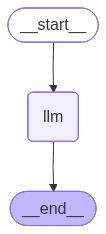

In [32]:
app

In [33]:
def ask(user_query: str):
    state = {"messages": [HumanMessage(content=user_query)]}
    out = app.invoke(state)
    return out["messages"][-1].content

In [34]:
CAN_ANSWER = [
    "1. According to the policy, when do you need explicit user confirmation before taking an action?",
    "2. Explain the checked-bag allowance rules for regular, Silver, and Gold members across cabin classes.",
]

In [35]:
CANNOT_ANSWER = [
    "1. Cancel reservation EHGLP3.",
    "2. I'm contacting to complain about my delayed flight HAT045 from PHX to SEA. What compensation can you issue?",
]

In [36]:
print("Can answer policy-based questions 👌🏻")
for q in CAN_ANSWER:
    print(f"\nUSER: {q}")
    print(f"AGENT: {ask(q)}")

Can answer policy-based questions 👌🏻

USER: 1. According to the policy, when do you need explicit user confirmation before taking an action?
AGENT: - The policy does not specify any requirement for explicit user confirmation before taking an action.

What I can do instead:
- Explain relevant policies.
- Ask clarifying questions to gather the information I’d need to proceed.
- Outline what information is required to take a requested action.

If you want, I can outline what kind of confirmation would typically be needed for specific actions (e.g., changing or canceling a booking), but the policy itself doesn’t mandate a formal confirmation trigger.

USER: 2. Explain the checked-bag allowance rules for regular, Silver, and Gold members across cabin classes.
AGENT: I don’t have access to your airline’s live policy or reservation data, so I can’t quote exact numbers. I can, however, explain the typical structure and what to look for, and then tailor the details once you share the airline or

In [37]:
print("\n\nCANNOT answer yet 😞")
for q in CANNOT_ANSWER:
    print(f"\nUSER: {q}")
    print(f"AGENT: {ask(q)}")



CANNOT answer yet 😞

USER: 1. Cancel reservation EHGLP3.
AGENT: I can’t access or cancel reservations directly (including EHGLP3). I can guide you through the steps or draft a cancellation request you can send to support. Here are your options:

Option 1: Cancel online (self-service)
- Log in to your account on our website or mobile app.
- Go to My Trips or Manage Booking.
- Find reservation EHGLP3.
- Select Cancel or Cancel Reservation.
- Review the fare rules and any fees, then confirm.
- You should receive a cancellation confirmation and details about refunds or credits if eligible.

Option 2: Cancel by contacting support
- Use the app/website chat, call our support line, or email.
- Have ready: reservation number (EHGLP3), passenger full name, contact info, and your preferred refund method (original payment method, travel voucher, or credit).
- Ask to cancel the reservation and request confirmation of any fees and the status of any refund or credit.

Notification and policies
- R